# CNN Emotion Training (Phase 2)
Fine-tunes MobileNetV2 on FER-2013, generates visualizations, saves to Google Drive, and pushes to Hugging Face.

In [6]:
!pip install datasets transformers tensorflow huggingface_hub Pillow matplotlib seaborn scikit-learn

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import tensorflow as tf
from datasets import load_dataset
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create explicit directories
CHECKPOINT_DIR = '/content/drive/MyDrive/PersonaPath/checkpoints'
VISUALIZATION_DIR = '/content/drive/MyDrive/PersonaPath/visualizations'
os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(VISUALIZATION_DIR, exist_ok=True)
print(f'Directories explicitly created at {CHECKPOINT_DIR} and {VISUALIZATION_DIR}')

Directories explicitly created at /content/drive/MyDrive/PersonaPath/checkpoints and /content/drive/MyDrive/PersonaPath/visualizations


In [21]:
from huggingface_hub import notebook_login
print('Log in to Hugging Face to push your model later:')
notebook_login()

Log in to Hugging Face to push your model later:


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AutumnQiu/fer2013' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.
ERROR:datasets.load:`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'AutumnQiu/fer2013' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


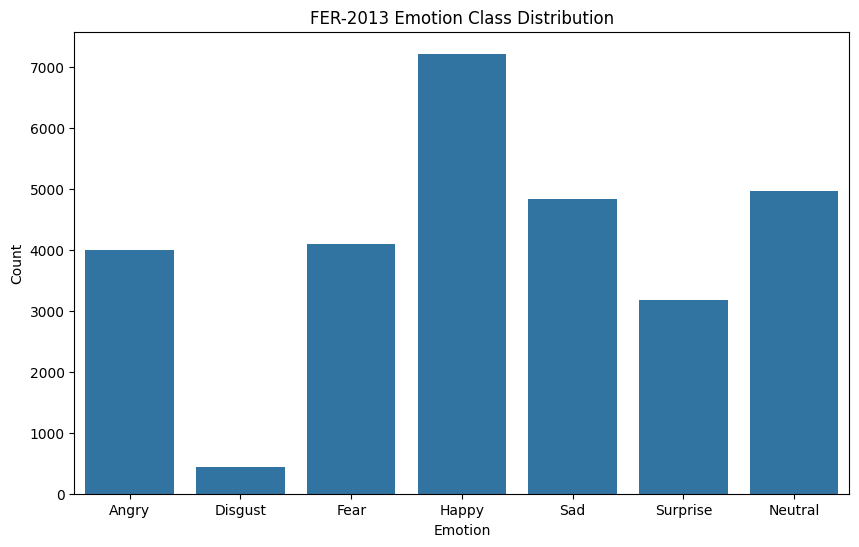

Saved distribution plot to /content/drive/MyDrive/PersonaPath/visualizations/cnn_class_distribution.png


In [22]:

dataset = load_dataset("AutumnQiu/fer2013", trust_remote_code=True)
emotion_labels = ['Angry', 'Disgust', 'Fear', 'Happy', 'Sad', 'Surprise', 'Neutral']

# VISUALIZATION 1: Class Distribution
labels = dataset['train']['label']
plt.figure(figsize=(10, 6))
sns.countplot(x=labels)
plt.title('FER-2013 Emotion Class Distribution')
plt.xticks(ticks=range(7), labels=emotion_labels)
plt.xlabel('Emotion')
plt.ylabel('Count')
dist_path = os.path.join(VISUALIZATION_DIR, 'cnn_class_distribution.png')
plt.savefig(dist_path)
plt.show()
print(f'Saved distribution plot to {dist_path}')

In [12]:
print(dataset)

DatasetDict({
    train: Dataset({
        features: ['label', 'image'],
        num_rows: 28709
    })
    valid: Dataset({
        features: ['label', 'image'],
        num_rows: 3589
    })
    test: Dataset({
        features: ['label', 'image'],
        num_rows: 3589
    })
})


In [13]:

print(dataset['train'][0])

{'label': 0, 'image': <PIL.PngImagePlugin.PngImageFile image mode=RGB size=48x48 at 0x79EE95B967B0>}


In [14]:
for i in range(5):
    print(f"Label ID: {dataset['train'][i]['label']} -> Emotion: {emotion_labels[dataset['train'][i]['label']]}")

Label ID: 0 -> Emotion: Angry
Label ID: 0 -> Emotion: Angry
Label ID: 2 -> Emotion: Fear
Label ID: 4 -> Emotion: Sad
Label ID: 6 -> Emotion: Neutral


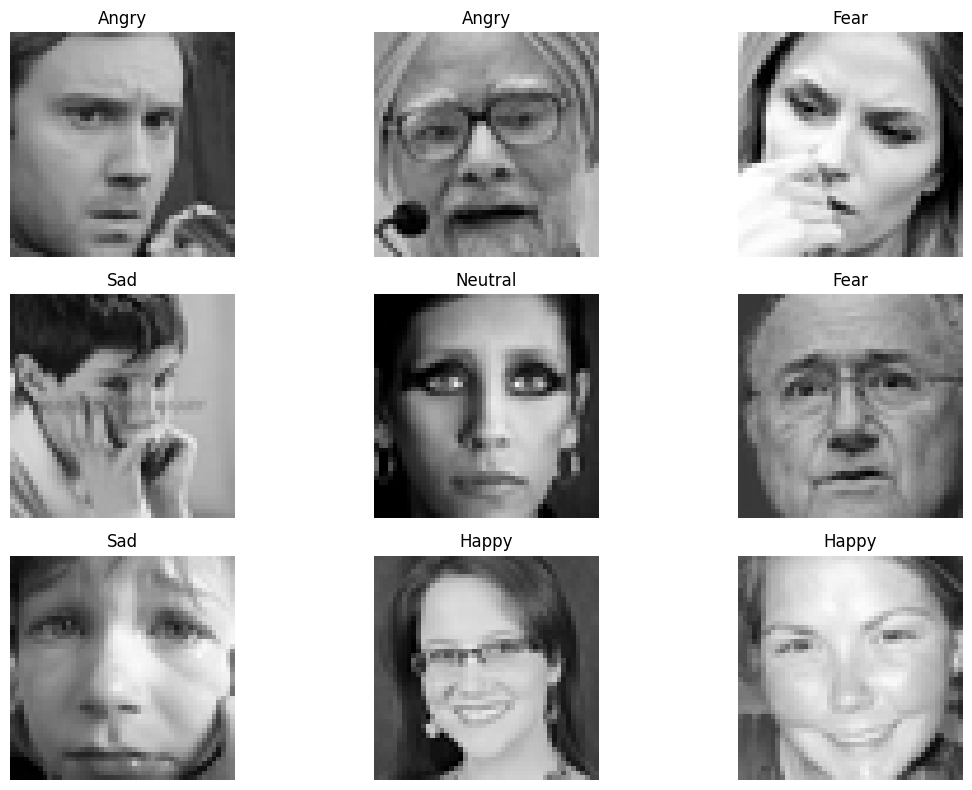

Saved raw sample images to /content/drive/MyDrive/PersonaPath/visualizations/cnn_raw_sample_images.png


In [15]:
# VISUALIZATION 2: Raw Sample Images (Before Preprocessing)
plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    example = dataset['train'][i]
    plt.imshow(example['image'], cmap='gray')
    plt.title(emotion_labels[example['label']])
    plt.axis('off')
plt.tight_layout()
samples_path = os.path.join(VISUALIZATION_DIR, 'cnn_raw_sample_images.png')
plt.savefig(samples_path)
plt.show()
print(f'Saved raw sample images to {samples_path}')

In [24]:
# 1. Setup Augmentation & Preprocessing Layers
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Resizing(224, 224), # Resizes raw input to MobileNet size
    tf.keras.layers.RandomFlip("horizontal"), # Improves model robustness
    tf.keras.layers.RandomRotation(0.1), # Helps with different camera angles
    tf.keras.layers.RandomZoom(0.1),
])


base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False # Keep base frozen

model = tf.keras.Sequential([
    # Input layer accepts raw RGB images of varying sizes
    tf.keras.layers.InputLayer(input_shape=(None, None, 3)),
    data_augmentation,
    # Scales pixels to [-1, 1] as required by MobileNetV2
    tf.keras.layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2), # Syllabus: Preventing Overfitting
    tf.keras.layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,855 (9.24 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [18]:

# 1. The Kill-Switch: Early Stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# 2. Drive Checkpointing
checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_model.keras'),
    save_best_only=True,
    monitor='val_accuracy'
)

print('Starting Training with Early Stopping...')
#
history = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=50,
    callbacks=[checkpoint_callback, early_stopping]
)

Starting Training with Early Stopping...
Epoch 1/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 62s 69ms/step - accuracy: 0.4075 - loss: 1.5328 - val_accuracy: 0.4525 - val_loss: 1.4184
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4310 - loss: 1.4641 - val_accuracy: 0.4542 - val_loss: 1.3963
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 62s 69ms/step - accuracy: 0.4477 - loss: 1.4387 - val_accuracy: 0.4812 - val_loss: 1.3528
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4555 - loss: 1.4130 - val_accuracy: 0.4806 - val_loss: 1.3480
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4597 - loss: 1.4028 - val_accuracy: 0.4857 - val_loss: 1.3396
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4626 - loss: 1.3931 - val_accuracy: 0.4912 - val_loss: 1.3136
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.4699 - loss: 1.3810 - val_accuracy: 0.4954 - val_loss: 1.3138
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/

In [27]:
import tensorflow as tf
import os

print("1. Rebuilding model architecture...")
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.Resizing(224, 224),
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

model = tf.keras.Sequential([
    tf.keras.layers.InputLayer(input_shape=(None, None, 3)),
    data_augmentation,
    tf.keras.layers.Lambda(lambda x: tf.keras.applications.mobilenet_v2.preprocess_input(x)),
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(128, activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(7, activation='softmax')
])

model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

print("2. Injecting saved weights from Drive...")
# This bypasses the bug by only loading the numbers, not the Python code!
model.load_weights(os.path.join(CHECKPOINT_DIR, 'cnn_emotion_model.keras'))

print("3. Resuming Training!")
# Re-initialize the kill-switches
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_model.keras'),
    save_best_only=True,
    monitor='val_accuracy'
)

# Kick off the training again!
history = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=50,
    callbacks=[checkpoint_callback, early_stopping]
)

1. Rebuilding model architecture...
2. Injecting saved weights from Drive...
3. Resuming Training!
Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


898/898 ━━━━━━━━━━━━━━━━━━━━ 66s 69ms/step - accuracy: 0.4863 - loss: 1.3346 - val_accuracy: 0.5088 - val_loss: 1.2785
Epoch 2/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.4876 - loss: 1.3316 - val_accuracy: 0.5082 - val_loss: 1.2757
Epoch 3/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.4919 - loss: 1.3197 - val_accuracy: 0.5102 - val_loss: 1.2705
Epoch 4/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 60s 66ms/step - accuracy: 0.4926 - loss: 1.3204 - val_accuracy: 0.5149 - val_loss: 1.2705
Epoch 5/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 66ms/step - accuracy: 0.4936 - loss: 1.3169 - val_accuracy: 0.5116 - val_loss: 1.2678
Epoch 6/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 72s 80ms/step - accuracy: 0.4982 - loss: 1.3149 - val_accuracy: 0.5183 - val_loss: 1.2587
Epoch 7/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 60s 67ms/step - accuracy: 0.4988 - loss: 1.3098 - val_accuracy: 0.5216 - val_loss: 1.2554
Epoch 8/50
898/898 ━━━━━━━━━━━━━━━━━━━━ 59s 65ms/step - accuracy: 0.5017 - loss: 1.3100 - val_accurac

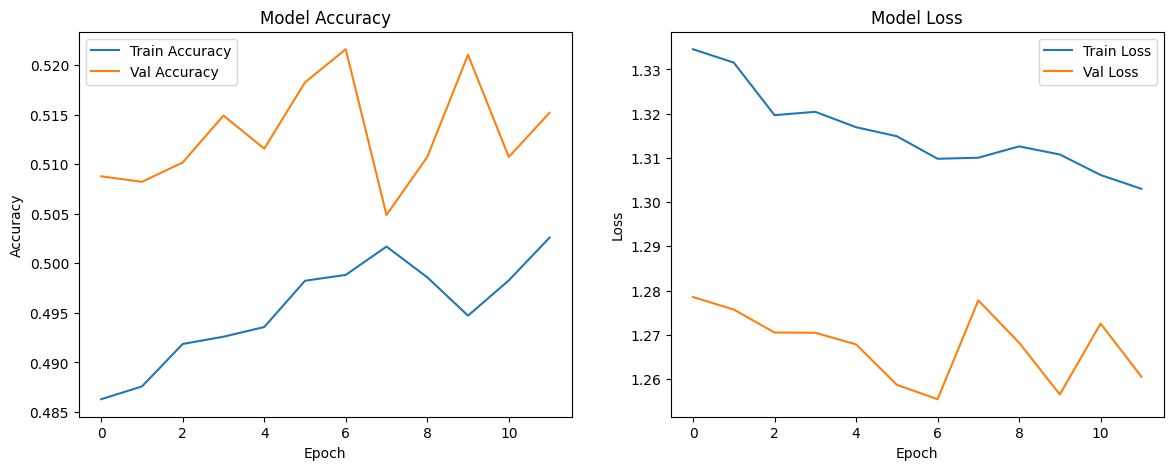

Saved training curves to /content/drive/MyDrive/PersonaPath/visualizations/cnn_training_curves.png


In [28]:
# VISUALIZATION 4: Training Curves
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

curves_path = os.path.join(VISUALIZATION_DIR, 'cnn_training_curves.png')
plt.savefig(curves_path)
plt.show()
print(f'Saved training curves to {curves_path}')

In [29]:

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

checkpoint_callback = tf.keras.callbacks.ModelCheckpoint(
    filepath=os.path.join(CHECKPOINT_DIR, 'cnn_emotion_refined.keras'),
    save_best_only=True,
    monitor='val_accuracy'
)

print('Starting Refined Training...')
history = model.fit(
    tf_train,
    validation_data=tf_val,
    epochs=30,
    callbacks=[checkpoint_callback, early_stopping, reduce_lr]
)

Starting Refined Training...
Epoch 1/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.4976 - loss: 1.3096 - val_accuracy: 0.5205 - val_loss: 1.2553 - learning_rate: 0.0010
Epoch 2/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.5003 - loss: 1.3078 - val_accuracy: 0.5043 - val_loss: 1.2728 - learning_rate: 0.0010
Epoch 3/30
897/898 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.4983 - loss: 1.3038
Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
898/898 ━━━━━━━━━━━━━━━━━━━━ 58s 65ms/step - accuracy: 0.4980 - loss: 1.3071 - val_accuracy: 0.5091 - val_loss: 1.2629 - learning_rate: 0.0010
Epoch 4/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 60s 67ms/step - accuracy: 0.5101 - loss: 1.2820 - val_accuracy: 0.5210 - val_loss: 1.2440 - learning_rate: 3.0000e-04
Epoch 5/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 61s 68ms/step - accuracy: 0.5125 - loss: 1.2705 - val_accuracy: 0.5183 - val_loss: 1.2391 - learning_rate: 3.0000e-04
Epoch 6/30
898/898 ━━━━━━━━━━━━━━━━━━━━ 6

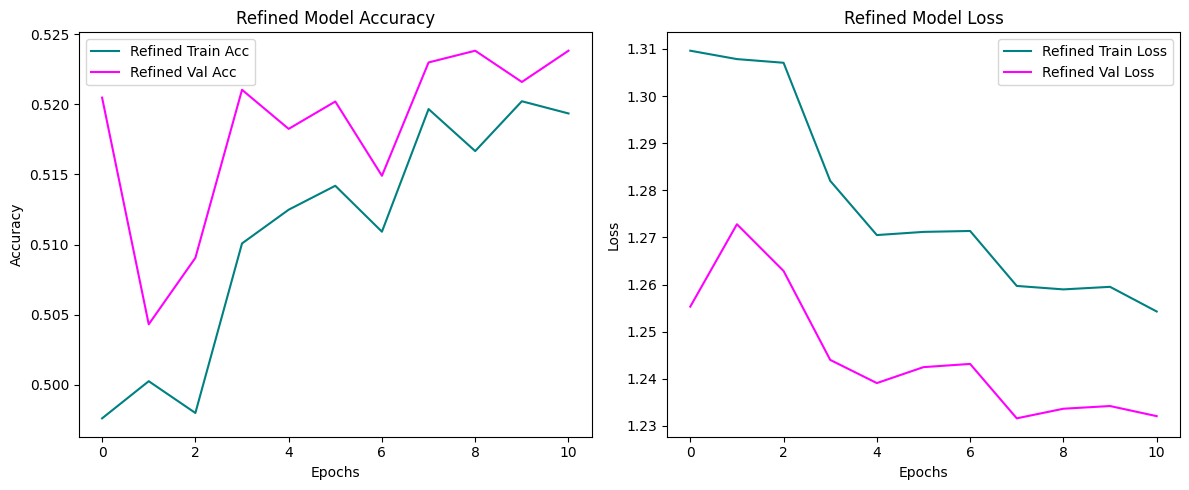

Refined curves saved to: /content/drive/MyDrive/PersonaPath/visualizations/refined_training_curves.png


In [30]:
# VISUALIZATION 5: Refined Training Curves (Comparison)
import matplotlib.pyplot as plt
import os

plt.figure(figsize=(12, 5))

# Plot 1: Accuracy (Looking for a higher, smoother orange line)
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Refined Train Acc', color='teal')
plt.plot(history.history['val_accuracy'], label='Refined Val Acc', color='magenta')
plt.title('Refined Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

# Plot 2: Loss (Looking for smaller "bounces" thanks to ReduceLROnPlateau)
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Refined Train Loss', color='teal')
plt.plot(history.history['val_loss'], label='Refined Val Loss', color='magenta')
plt.title('Refined Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
refined_path = os.path.join(VISUALIZATION_DIR, 'refined_training_curves.png')
plt.savefig(refined_path)
plt.show()

print(f"Refined curves saved to: {refined_path}")

In [ ]:
from huggingface_hub import push_to_hub_keras

repo_id = input('Enter your HF repo ID (e.g., username/personapath-emotion-cnn): ')
try:
    push_to_hub_keras(model, repo_id)
    print(f'Model successfully pushed to https://huggingface.co/{repo_id}')
except Exception as e:
    print('Error pushing to HF:', e)